In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/metatron-app/metatron-doc-discovery/master/_static/data/sales-data-sample.csv"

df = pd.read_csv(url, encoding="ISO-8859-1")

df.columns = df.columns.str.strip().str.upper()

In [ ]:
from datetime import timedelta

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

snapshot_date = df['ORDERDATE'].max() + timedelta(days=1)

def calculate_recency(date_series):
    latest_order_date = date_series.max()
    days_passed = (snapshot_date - latest_order_date).days
    return days_passed


rfm = df.groupby('CUSTOMERNAME').agg({
    'ORDERDATE': calculate_recency,
    'ORDERID': 'nunique',
    'SALES': 'sum'
})


rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM Metrics Successfully Calculated!")
print(rfm.head())

RFM Metrics Successfully Calculated!
                 Recency  Frequency  Monetary
CUSTOMERNAME                                 
Aaron Bergman        416          3       887
Aaron Hawkins         13          7      1744
Aaron Smayling        89          7      3051
Adam Bellavance       55          8      7757
Adam Hart             35         10      3251


In [ ]:
print(df.columns.tolist())

['ORDERDATE', 'CATEGORY', 'CITY', 'COUNTRY', 'CUSTOMERNAME', 'DISCOUNT', 'ORDERID', 'POSTALCODE', 'PRODUCTNAME', 'PROFIT', 'QUANTITY', 'REGION', 'SALES', 'SEGMENT', 'SHIPDATE', 'SHIPMODE', 'STATE', 'SUB_CATEGORY', 'DAYSTOSHIPACTUAL', 'SALESFORECAST', 'SHIPSTATUS', 'DAYSTOSHIPSCHEDULED', 'ORDERPROFITABLE', 'SALESPERCUSTOMER', 'PROFITRATIO', 'SALESABOVETARGET', 'LATITUDE', 'LONGITUDE']


In [ ]:

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("RFM scores(1-4) succesfully calculated!")
print(rfm.head())

RFM scores(1-4) succesfully calculated!
                 Recency  Frequency  Monetary R_Score F_Score M_Score  \
CUSTOMERNAME                                                            
Aaron Bergman        416          3       887       1       1       1   
Aaron Hawkins         13          7      1744       4       3       2   
Aaron Smayling        89          7      3051       2       3       3   
Adam Bellavance       55          8      7757       3       3       4   
Adam Hart             35         10      3251       3       4       3   

                RFM_Score  
CUSTOMERNAME               
Aaron Bergman         111  
Aaron Hawkins         432  
Aaron Smayling        233  
Adam Bellavance       334  
Adam Hart             343  


In [ ]:
# calculating segmentation according to scores

def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])

    if r >= 3 and f >= 3:
        return 'Champions'
    elif r >= 2 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Promising / Recent'
    elif r <= 2 and f >= 3:
        return "At Risk / Can't Lose"
    else:
        return 'Hibernating / Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm[['Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment']].head(10))

                    Recency  Frequency  Monetary RFM_Score             Segment
CUSTOMERNAME                                                                  
Aaron Bergman           416          3       887       111  Hibernating / Lost
Aaron Hawkins            13          7      1744       432           Champions
Aaron Smayling           89          7      3051       233     Loyal Customers
Adam Bellavance          55          8      7757       334           Champions
Adam Hart                35         10      3251       343           Champions
Adam Shillingsburg       29          9      3255       443           Champions
Adrian Barton            42         10     14476       344           Champions
Adrian Hane              61          7      1736       332           Champions
Adrian Shami             42          2        58       311  Promising / Recent
Aimee Bixby              42          5       969       311  Promising / Recent


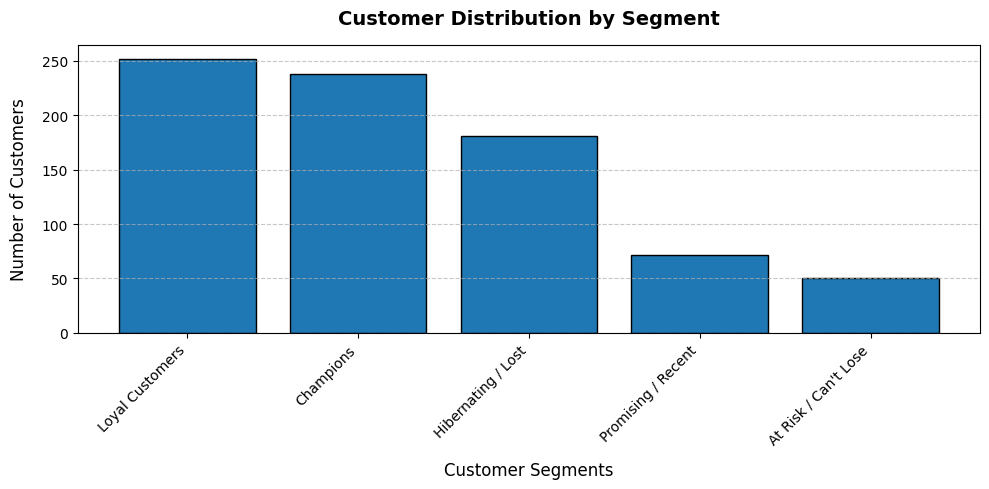

In [ ]:
# total customer counts per segment

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(segment_counts.index, segment_counts.values, edgecolor='black')

plt.title('Customer Distribution by Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segments', fontsize=12, labelpad=10)
plt.ylabel('Number of Customers', fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

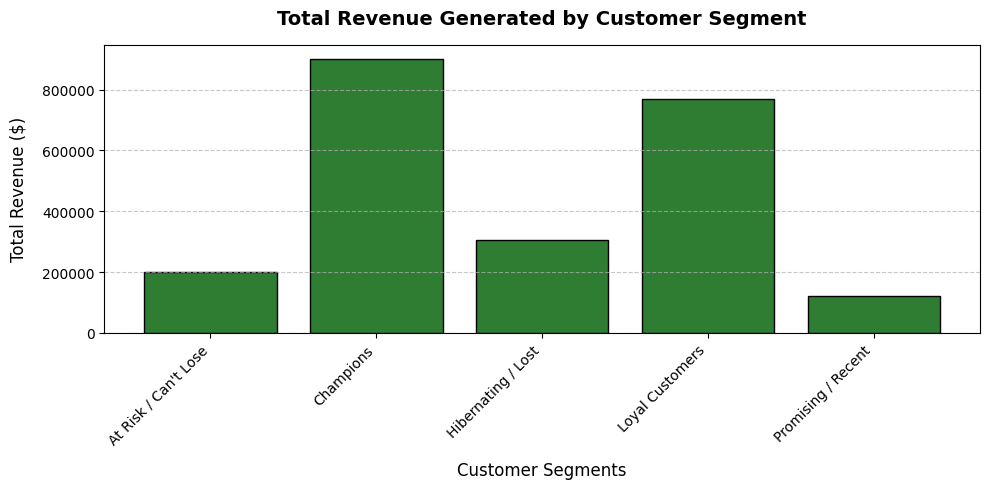

In [ ]:
# total revenue per segment

segment_revenue = rfm.groupby('Segment')['Monetary'].sum()

fig = plt.figure(figsize=(10, 5))
fig.set_facecolor('white')

plt.bar(segment_revenue.index, segment_revenue.values, color='#2e7d32', edgecolor='black')

plt.title('Total Revenue Generated by Customer Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segments', fontsize=12, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

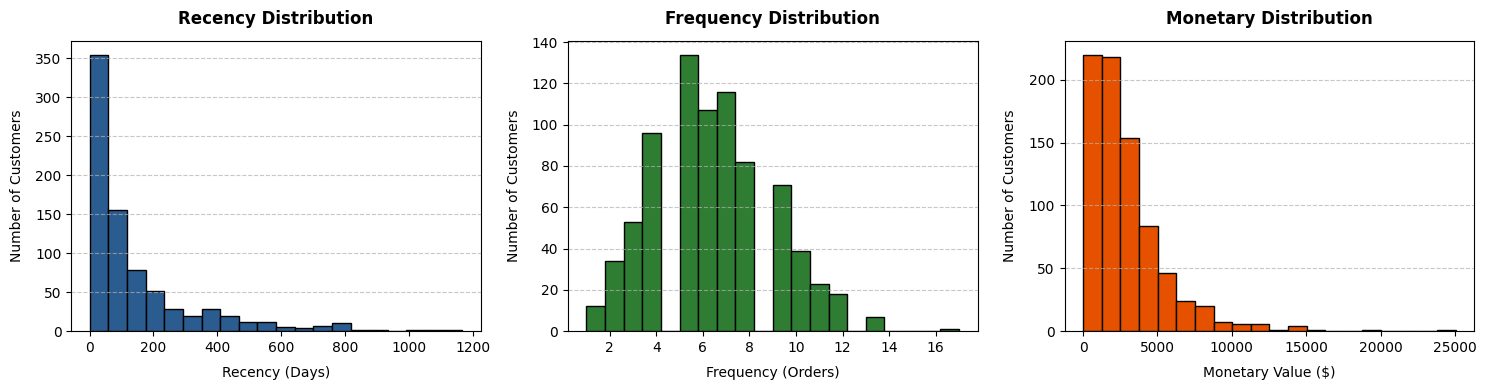

In [ ]:
# distribution of rfm metrics by histogram

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.set_facecolor('white')

axes[0].hist(rfm['Recency'], bins=20, color='#2b5c8f', edgecolor='black')
axes[0].set_title('Recency Distribution', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Recency (Days)', labelpad=8)
axes[0].set_ylabel('Number of Customers', labelpad=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].hist(rfm['Frequency'], bins=20, color='#2e7d32', edgecolor='black')
axes[1].set_title('Frequency Distribution', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Frequency (Orders)', labelpad=8)
axes[1].set_ylabel('Number of Customers', labelpad=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

axes[2].hist(rfm['Monetary'], bins=20, color='#e65100', edgecolor='black')
axes[2].set_title('Monetary Distribution', fontsize=12, fontweight='bold', pad=12)
axes[2].set_xlabel('Monetary Value ($)', labelpad=8)
axes[2].set_ylabel('Number of Customers', labelpad=8)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

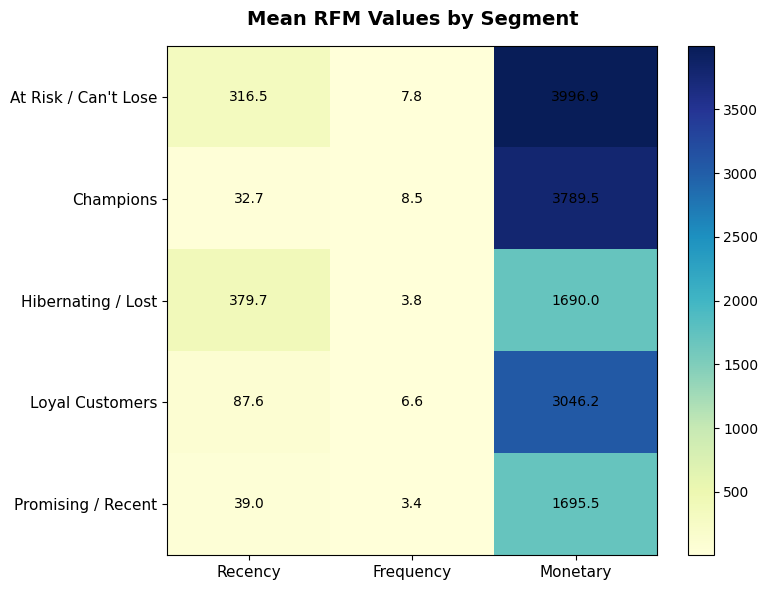

In [ ]:
# RFM segment mean each matrix

import numpy as np

segment_summary = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

data = segment_summary.values

fig, ax = plt.subplots(figsize=(8, 6))
fig.set_facecolor('white')

cax = ax.imshow(data, cmap='YlGnBu', aspect='auto')

fig.colorbar(cax)

ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))

ax.set_xticklabels(segment_summary.columns, fontsize=11)
ax.set_yticklabels(segment_summary.index, fontsize=11)

plt.title('Mean RFM Values by Segment', fontsize=14, fontweight='bold', pad=15)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]:.1f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()